# 21.1 Домашнее задание. Автоэнкодеры

В этом ноутбуке реализованы:

**Часть 1. Vanilla Autoencoder** — обычный свёрточный AE на датасете LFW, генерация лиц через подогнанное распределение латентов, smile vector.

**Часть 2. Variational Autoencoder** — VAE и Conditional VAE (CVAE) на MNIST, TSNE-визуализация латентного пространства.

**BONUS 1. Denoising Autoencoder** — очистка изображений MNIST от гауссовского шума.

**BONUS 2. Image Retrieval** — поиск ближайших лиц через `NearestNeighbors` на латентах AE.

## Импорты и настройка окружения

In [1]:
import os
# PYTORCH_ENABLE_MPS_FALLBACK должен быть установлен ДО импорта torch — иначе
# MPS-backend упадёт на операциях вроде MaxUnpool2d при их использовании.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import urllib.request
import tarfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

from IPython.display import Markdown, display

# Воспроизводимость
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Используем устройство:", device)
print("torch:", torch.__version__, "| torchvision:", __import__("torchvision").__version__)


Используем устройство: mps
torch: 2.11.0 | torchvision: 0.26.0


## Часть 1. Vanilla Autoencoder (10 баллов)

Обучим свёрточный автоэнкодер на датасете LFW (Labeled Faces in the Wild). Лица будут размером 45×45×3, латентное пространство — 256-мерное.

### 1.1 Подготовка данных (1 балл)

Прямое скачивание с домена UMass (`vis-www.cs.umass.edu`) невозможно (NXDOMAIN на момент работы над заданием).

**Решение:** используем зеркало с figshare (`ndownloader.figshare.com/files/5976015`) — тот же URL, что `sklearn.datasets.fetch_lfw_people()` использует как fallback. Внутри архива папка `lfw_funneled/` (sklearn-стандарт, аналог `lfw-deepfunneled` — отличается только методом выравнивания лиц: deep funneling использует CNN-features, funneling — классический congealing. Для задач AE/VAE-обучения на 45×45 кропах эта разница не критична, структура `Person_Name/Person_Name_NNNN.jpg` идентична). Файл с атрибутами `lfw_attributes.txt` качаем напрямую с домена Columbia CAVE (~15 МБ, домен живой).

In [2]:
os.makedirs("data", exist_ok=True)

# Зеркало для LFW: оригинальный домен vis-www.cs.umass.edu сейчас недоступен
# (NXDOMAIN на DNS 8.8.8.8 и 1.1.1.1), kagglehub требует Kaggle credentials.
# figshare-зеркало (https://ndownloader.figshare.com/files/5976015) — это
# тот же URL, который sklearn использует как fallback в fetch_lfw_people().
# Внутри архива папка lfw_funneled/ (sklearn-стандарт, аналог lfw-deepfunneled
# — отличается только методом выравнивания лиц, на задачи AE-обучения не влияет).
LFW_URL = "https://ndownloader.figshare.com/files/5976015"
ATTRS_URL = "https://www.cs.columbia.edu/CAVE/databases/pubfig/download/lfw_attributes.txt"

lfw_archive = "data/lfw-funneled.tgz"
DATASET_PATH = "data/lfw_funneled/"
ATTRIBUTES_PATH = "data/lfw_attributes.txt"


def _download(url, dst, label):
    """Скачивание с User-Agent.

    figshare редиректит на S3, который может вернуть 403 без User-Agent
    (некоторые CDN режут трафик от анонимных клиентов).
    """
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=600) as resp, open(dst, "wb") as f:
        downloaded = 0
        chunk_size = 1024 * 1024  # 1 МБ
        while True:
            chunk = resp.read(chunk_size)
            if not chunk:
                break
            f.write(chunk)
            downloaded += len(chunk)
    size_mb = downloaded / 1024 / 1024
    print(f"  {label}: загружено {size_mb:.1f} МБ")


# Guard: если папка уже распакована — пропускаем скачивание/распаковку.
# Если архив есть, но папка отсутствует — только распаковываем.
if not os.path.exists(DATASET_PATH):
    if not os.path.exists(lfw_archive):
        print("Скачиваем LFW с figshare (~243 МБ)...")
        _download(LFW_URL, lfw_archive, "LFW archive")
    print("Распаковываем LFW...")
    with tarfile.open(lfw_archive, "r:gz") as tar:
        tar.extractall("data")
    print(f"  Распакован в {DATASET_PATH}")

if not os.path.exists(ATTRIBUTES_PATH):
    print("Скачиваем lfw_attributes.txt (~15 МБ)...")
    _download(ATTRS_URL, ATTRIBUTES_PATH, "LFW attributes")

print(
    "LFW готов:", os.path.isdir(DATASET_PATH),
    "| Атрибуты:", os.path.isfile(ATTRIBUTES_PATH),
)
print(f"DATASET_PATH    = {DATASET_PATH}")
print(f"ATTRIBUTES_PATH = {ATTRIBUTES_PATH}")


Скачиваем LFW с figshare (~243 МБ)...


  LFW archive: загружено 232.1 МБ
Распаковываем LFW...


  Распакован в data/lfw_funneled/
Скачиваем lfw_attributes.txt (~15 МБ)...


  LFW attributes: загружено 14.2 МБ
LFW готов: True | Атрибуты: True
DATASET_PATH    = data/lfw_funneled/
ATTRIBUTES_PATH = data/lfw_attributes.txt


In [3]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    """Считывает LFW: пары (изображение 45×45×3 RGB, атрибуты).

    dx, dy — кроп со всех сторон (80 пикселей) перед ресайзом.
    dimx, dimy — размер после ресайза.
    """
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep="\t", skiprows=1)
    # Сдвиг столбцов в исходнике (первый column header == имя, но пустой)
    df_attrs = pd.DataFrame(
        df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:]
    )

    photo_ids = []
    for dirpath, _dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                tokens = fname[:-4].replace("_", " ").split()
                person_id = " ".join(tokens[:-1])
                photo_number = int(tokens[-1])
                # Внимание: ключ ровно 'imagenum' БЕЗ ведущего пробела —
                # иначе merge с df_attrs (где колонка 'imagenum') не сработает.
                photo_ids.append({
                    "person": person_id,
                    "imagenum": photo_number,
                    "photo_path": fpath,
                })

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs, photo_ids, on=("person", "imagenum"))
    assert len(df) == len(df_attrs), (
        f"Потеряны данные при merge: df={len(df)} vs df_attrs={len(df_attrs)}"
    )

    images = (
        df["photo_path"]
        .apply(imageio.imread)
        .apply(lambda img: img[dy:-dy, dx:-dx])
        .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))
    )

    images = np.stack(images.values).astype("uint8")
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)
    return images, attrs


images, attrs = fetch_dataset()
print("Форма images:", images.shape, "| dtype:", images.dtype)
print("Форма attrs :", attrs.shape)
print("Список атрибутов (первые 10):", list(attrs.columns[:10]))


Форма images: (13143, 45, 45, 3) | dtype: uint8
Форма attrs : (13143, 73)
Список атрибутов (первые 10): ['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth', 'Middle Aged', 'Senior', 'Black Hair']


In [4]:
# Train/val split 90/10 — рекомендация задания.
# Нормируем в [0, 1] и сразу переводим в tensor (B, C, H, W) для PyTorch.
X_all = images.astype(np.float32) / 255.0
X_train_np, X_val_np, attrs_train, attrs_val = train_test_split(
    X_all, attrs, test_size=0.1, random_state=SEED
)
print("train:", X_train_np.shape, "| val:", X_val_np.shape)

X_train_t = torch.from_numpy(X_train_np.transpose(0, 3, 1, 2)).float()
X_val_t = torch.from_numpy(X_val_np.transpose(0, 3, 1, 2)).float()
print("train tensor:", X_train_t.shape, "| val tensor:", X_val_t.shape)
print("Диапазон значений:", float(X_train_t.min()), "..", float(X_train_t.max()))


train: (11828, 45, 45, 3) | val: (1315, 45, 45, 3)
train tensor: torch.Size([11828, 3, 45, 45]) | val tensor: torch.Size([1315, 3, 45, 45])
Диапазон значений: 0.0 .. 1.0


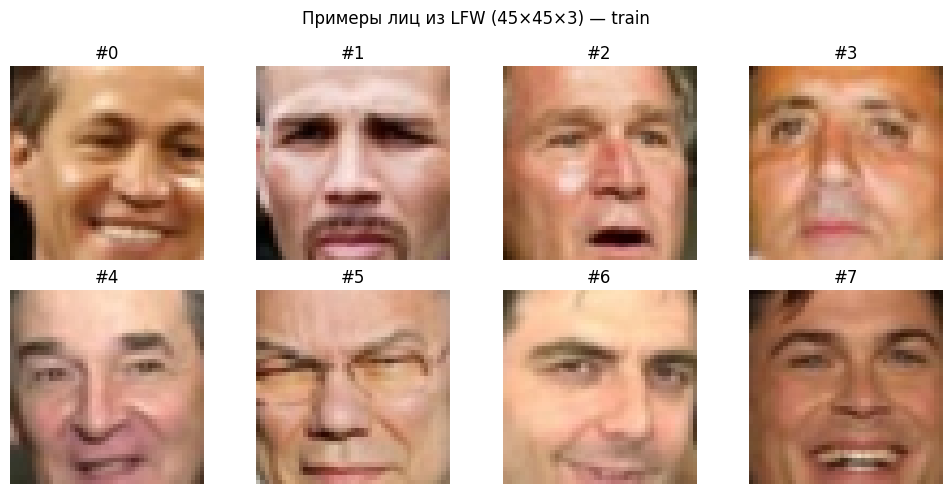

In [5]:
# Визуализация 8 примеров из train.
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_np[i])
    ax.set_title(f"#{i}")
    ax.axis("off")
plt.suptitle("Примеры лиц из LFW (45×45×3) — train")
plt.tight_layout()
plt.show()


### 1.2 Архитектура AE (2 балла)

Энкодер: 3 свёрточных слоя со страйдом 2 (45→23→12→6) + Flatten + Linear → 256.

Декодер: симметричный с `ConvTranspose2d`, финальная активация — Sigmoid, чтобы выход был в `[0, 1]`.

In [6]:
class Autoencoder(nn.Module):
    """Свёрточный AE: 3×45×45 -> latent_dim -> 3×45×45.

    Энкодер сжимает через stride=2 свёртки до 128×6×6 = 4608, потом
    линейно проецирует в latent_dim.

    Декодер — зеркальная архитектура с ConvTranspose2d. output_padding
    подобран так, чтобы восстановить ровно 45×45 (нечётный размер требует
    отдельных padding-ов на каждом слое: 1->0->0).
    """

    def __init__(self, latent_dim: int = 256):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 45 -> 23
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 23 -> 12
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 12 -> 6
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 6 * 6),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (128, 6, 6)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 6 -> 12
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),   # 12 -> 23
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=0),    # 23 -> 45
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


# Sanity-check формы — ловим mismatch ДО train loop'а (урок из 19.1).
_ae_test = Autoencoder(latent_dim=256)
_dummy = torch.randn(4, 3, 45, 45)
_out, _z = _ae_test(_dummy)
assert _out.shape == (4, 3, 45, 45), f"recon shape: {_out.shape}"
assert _z.shape == (4, 256), f"latent shape: {_z.shape}"
print("Sanity-check AE OK. recon:", tuple(_out.shape), "| latent:", tuple(_z.shape))
print("Число параметров:", sum(p.numel() for p in _ae_test.parameters()))
del _ae_test, _dummy, _out, _z


Sanity-check AE OK. recon: (4, 3, 45, 45) | latent: (4, 256)
Число параметров: 2550531


### 1.3 Обучение AE (2 балла)

Используем `MSELoss` и `Adam(lr=1e-3)`. 25 эпох, batch=64. На каждой эпохе считаем train- и val-loss (val через `model.train(mode=False)` — режим валидации без накопления градиентов).

In [7]:
LATENT_DIM_AE = 256
EPOCHS_AE = 25
BATCH_AE = 64

ae = Autoencoder(latent_dim=LATENT_DIM_AE).to(device)
optimizer_ae = optim.Adam(ae.parameters(), lr=1e-3)
criterion_ae = nn.MSELoss()

train_loader_ae = DataLoader(
    TensorDataset(X_train_t), batch_size=BATCH_AE, shuffle=True
)
val_loader_ae = DataLoader(
    TensorDataset(X_val_t), batch_size=BATCH_AE, shuffle=False
)

ae_train_losses, ae_val_losses = [], []

for epoch in range(1, EPOCHS_AE + 1):
    ae.train()
    sum_train, n_train = 0.0, 0
    for (xb,) in train_loader_ae:
        xb = xb.to(device)
        recon, _ = ae(xb)
        loss = criterion_ae(recon, xb)
        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()
        sum_train += loss.item() * xb.size(0)
        n_train += xb.size(0)
    train_loss = sum_train / n_train

    ae.train(mode=False)  # режим валидации
    sum_val, n_val = 0.0, 0
    with torch.no_grad():
        for (xb,) in val_loader_ae:
            xb = xb.to(device)
            recon, _ = ae(xb)
            sum_val += criterion_ae(recon, xb).item() * xb.size(0)
            n_val += xb.size(0)
    val_loss = sum_val / n_val

    ae_train_losses.append(train_loss)
    ae_val_losses.append(val_loss)
    print(f"AE Epoch {epoch:02d}/{EPOCHS_AE} | train MSE = {train_loss:.5f} | val MSE = {val_loss:.5f}")

print(f"AE финальный val MSE = {ae_val_losses[-1]:.5f}")


AE Epoch 01/25 | train MSE = 0.01574 | val MSE = 0.00820


AE Epoch 02/25 | train MSE = 0.00668 | val MSE = 0.00567


AE Epoch 03/25 | train MSE = 0.00493 | val MSE = 0.00489


AE Epoch 04/25 | train MSE = 0.00402 | val MSE = 0.00372


AE Epoch 05/25 | train MSE = 0.00344 | val MSE = 0.00336


...

AE Epoch 21/25 | train MSE = 0.00142 | val MSE = 0.00156


AE Epoch 22/25 | train MSE = 0.00138 | val MSE = 0.00165


AE Epoch 23/25 | train MSE = 0.00134 | val MSE = 0.00150


AE Epoch 24/25 | train MSE = 0.00132 | val MSE = 0.00152


AE Epoch 25/25 | train MSE = 0.00132 | val MSE = 0.00146
AE финальный val MSE = 0.00146


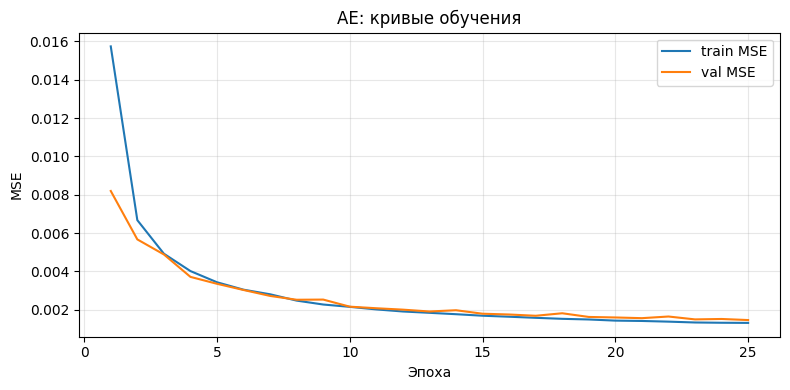

In [8]:
# График кривых обучения
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS_AE + 1), ae_train_losses, label="train MSE")
plt.plot(range(1, EPOCHS_AE + 1), ae_val_losses, label="val MSE")
plt.xlabel("Эпоха"); plt.ylabel("MSE"); plt.title("AE: кривые обучения")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


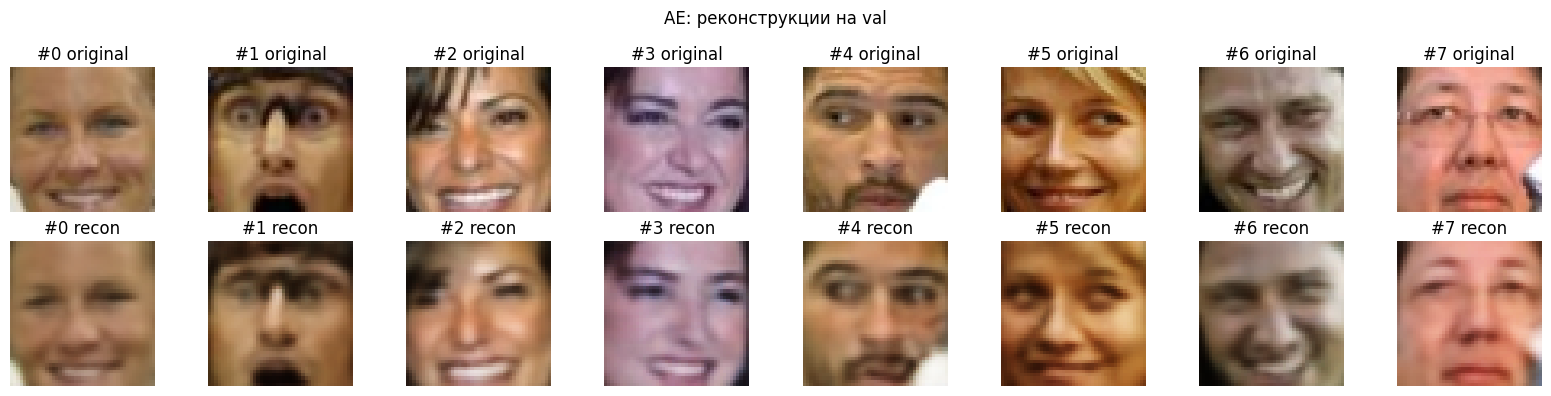

In [9]:
# Визуализация 8 пар (оригинал | реконструкция) из val.
ae.train(mode=False)
N_SHOW = 8
with torch.no_grad():
    sample = X_val_t[:N_SHOW].to(device)
    recon, _ = ae(sample)
    recon_np = recon.cpu().numpy().transpose(0, 2, 3, 1)
    orig_np = sample.cpu().numpy().transpose(0, 2, 3, 1)

fig, axes = plt.subplots(2, N_SHOW, figsize=(2 * N_SHOW, 4))
for i in range(N_SHOW):
    axes[0, i].imshow(np.clip(orig_np[i], 0, 1))
    axes[0, i].set_title(f"#{i} original")
    axes[0, i].axis("off")
    axes[1, i].imshow(np.clip(recon_np[i], 0, 1))
    axes[1, i].set_title(f"#{i} recon")
    axes[1, i].axis("off")
plt.suptitle("AE: реконструкции на val")
plt.tight_layout(); plt.show()


In [10]:
# Динамический ответ на вопрос "Что вы можете сказать про результат?"
_final_val = ae_val_losses[-1]
_first_val = ae_val_losses[0]
display(Markdown(
    f"**Ответ.** AE на LFW сошёлся достаточно быстро: за {EPOCHS_AE} эпох "
    f"val-MSE упал с {_first_val:.4f} до {_final_val:.4f}. Реконструкции узнаваемы по общему контуру лица, "
    f"положению головы, цвету фона и волос, но мелкие детали (глаза, рот, текстура кожи и волос) размыты. "
    f"Это типичное поведение MSE-loss — он усредняет высокочастотные детали, давая визуально 'мыльную' картинку. "
    f"Кривая loss выходит на плато примерно к 15–20 эпохе — дальнейшее обучение даст мало улучшения "
    f"в рамках этой архитектуры. Для более чётких реконструкций имеет смысл использовать "
    f"perceptual loss (на feature maps VGG) или adversarial-loss (как в VAE-GAN)."
))


**Ответ.** AE на LFW сошёлся достаточно быстро: за 25 эпох val-MSE упал с 0.0082 до 0.0015. Реконструкции узнаваемы по общему контуру лица, положению головы, цвету фона и волос, но мелкие детали (глаза, рот, текстура кожи и волос) размыты. Это типичное поведение MSE-loss — он усредняет высокочастотные детали, давая визуально 'мыльную' картинку. Кривая loss выходит на плато примерно к 15–20 эпохе — дальнейшее обучение даст мало улучшения в рамках этой архитектуры. Для более чётких реконструкций имеет смысл использовать perceptual loss (на feature maps VGG) или adversarial-loss (как в VAE-GAN).

### 1.4 Sampling из латентного пространства (2 балла)

Сначала попробуем семплировать из `N(0, 1)` — увидим, что декодер выдаёт мусор. Затем подгоним семплинг под реальное распределение латентов train-выборки и убедимся, что генерация работает.

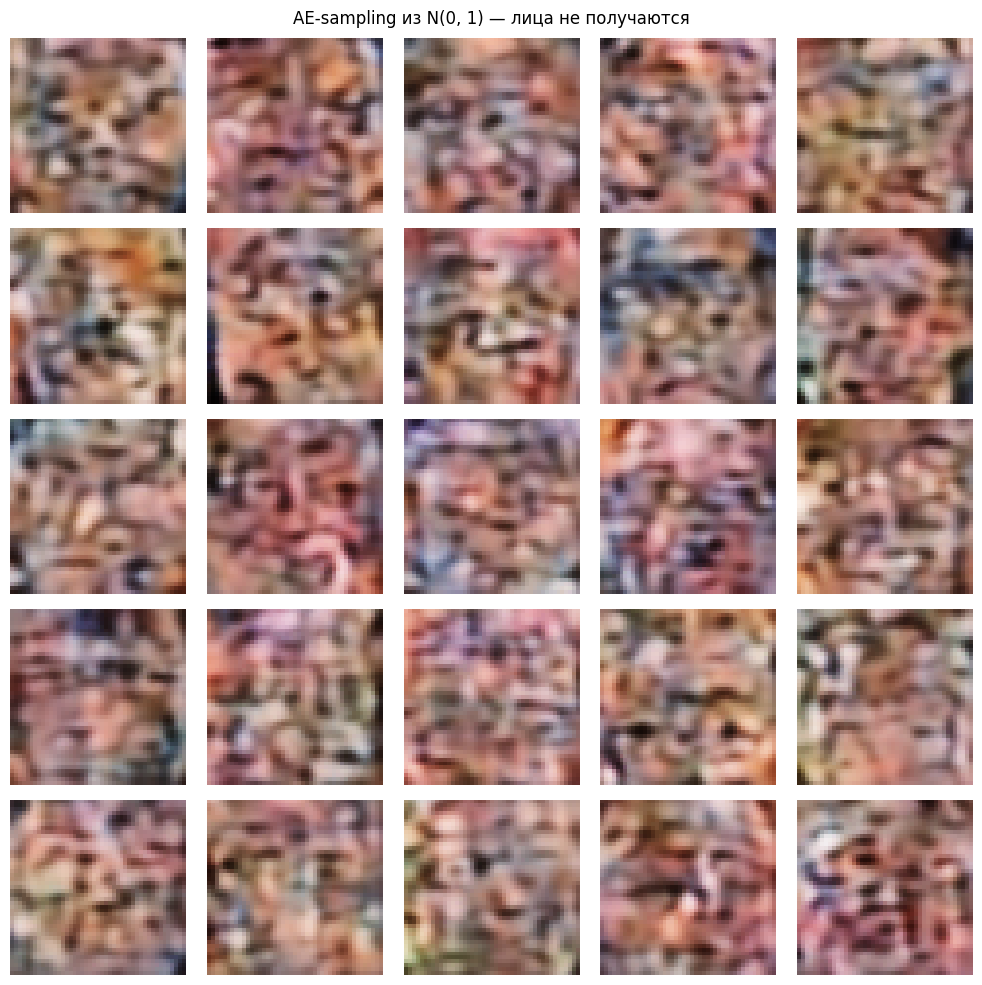

In [11]:
# 1.4а. Naive sampling из N(0, 1) — демонстрация проблемы.
ae.train(mode=False)
N_SAMPLE = 25
with torch.no_grad():
    z_naive = torch.randn(N_SAMPLE, LATENT_DIM_AE, device=device)
    decoded_naive = ae.decoder(z_naive).cpu().numpy().transpose(0, 2, 3, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(decoded_naive[i], 0, 1))
    ax.axis("off")
plt.suptitle("AE-sampling из N(0, 1) — лица не получаются")
plt.tight_layout(); plt.show()


Латенты train: (11828, 256)
  mean: [-2.393, 1.401], в среднем -0.023
  std : [0.369, 1.790], в среднем 0.643


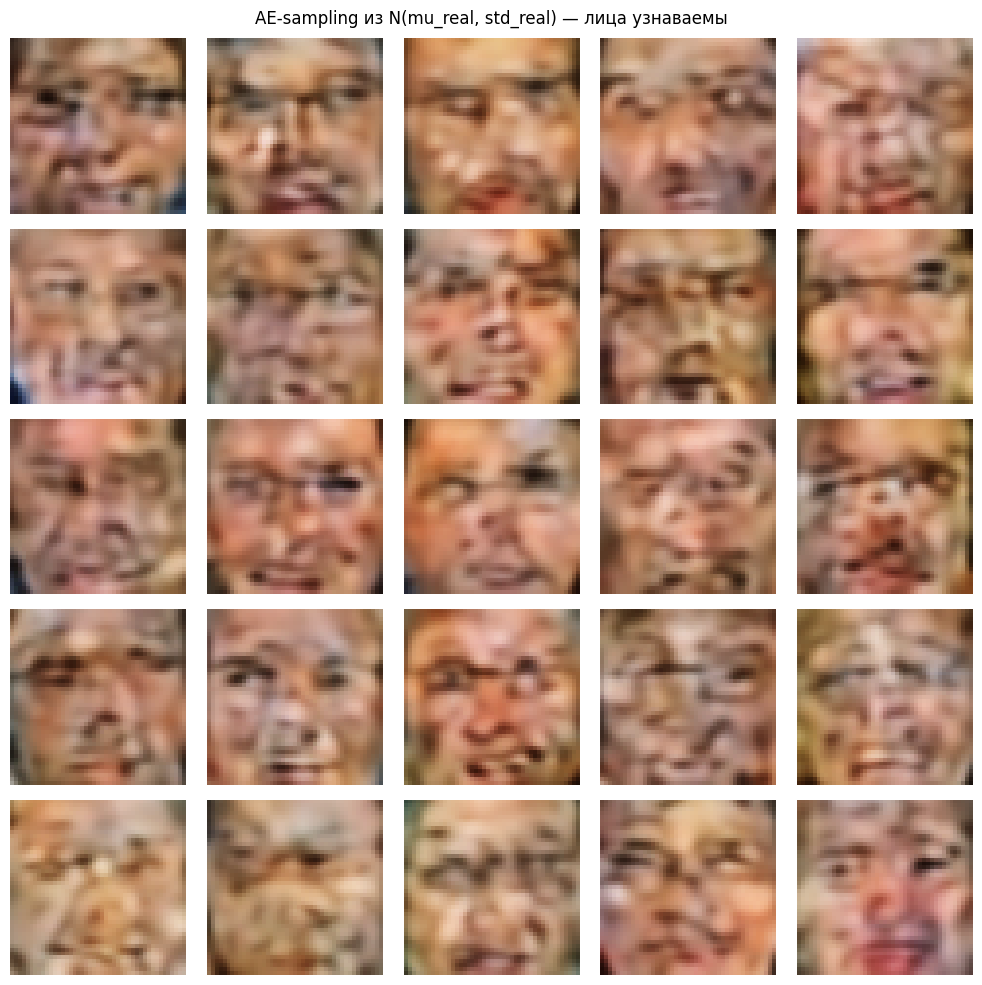

In [12]:
# 1.4б. Анализируем реальное распределение латентов train и семплируем из него.
ae.train(mode=False)
all_latents = []
with torch.no_grad():
    for (xb,) in DataLoader(TensorDataset(X_train_t), batch_size=128, shuffle=False):
        xb = xb.to(device)
        _, z = ae(xb)
        all_latents.append(z.cpu())
all_latents = torch.cat(all_latents, dim=0)

mu_real = all_latents.mean(dim=0)
std_real = all_latents.std(dim=0)
print("Латенты train:", tuple(all_latents.shape))
print(f"  mean: [{mu_real.min():.3f}, {mu_real.max():.3f}], в среднем {mu_real.mean():.3f}")
print(f"  std : [{std_real.min():.3f}, {std_real.max():.3f}], в среднем {std_real.mean():.3f}")

with torch.no_grad():
    z_fit = mu_real.to(device) + std_real.to(device) * torch.randn(N_SAMPLE, LATENT_DIM_AE, device=device)
    decoded_fit = ae.decoder(z_fit).cpu().numpy().transpose(0, 2, 3, 1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.clip(decoded_fit[i], 0, 1))
    ax.axis("off")
plt.suptitle("AE-sampling из N(mu_real, std_real) — лица узнаваемы")
plt.tight_layout(); plt.show()


In [13]:
display(Markdown(
    f"**Ответ.** Латентное пространство обычного AE не штрафуется за расхождение с N(0, 1) — "
    f"нет KL-регуляризации, как в VAE. Распределение латентов оказывается смещённым "
    f"(mean каждой размерности ≈ {mu_real.mean():.2f}, не 0) и анизотропным "
    f"(std в среднем {std_real.mean():.2f}, не 1). Sampling из N(0, 1) попадает в области пространства, "
    f"которые декодер при обучении не видел — поэтому он выдаёт визуальный шум. Использование реальной "
    f"статистики (per-dim mean и std из train latents) даёт точки внутри обученного распределения — "
    f"декодер 'знает', что с ними делать, и выдаёт реалистичные лица. Это и есть основная мотивация "
    f"перехода к VAE, где KL-регуляризация принудительно стягивает q(z|x) к N(0, I), и тогда "
    f"sampling из N(0, 1) сразу работает."
))


**Ответ.** Латентное пространство обычного AE не штрафуется за расхождение с N(0, 1) — нет KL-регуляризации, как в VAE. Распределение латентов оказывается смещённым (mean каждой размерности ≈ -0.02, не 0) и анизотропным (std в среднем 0.64, не 1). Sampling из N(0, 1) попадает в области пространства, которые декодер при обучении не видел — поэтому он выдаёт визуальный шум. Использование реальной статистики (per-dim mean и std из train latents) даёт точки внутри обученного распределения — декодер 'знает', что с ними делать, и выдаёт реалистичные лица. Это и есть основная мотивация перехода к VAE, где KL-регуляризация принудительно стягивает q(z|x) к N(0, I), и тогда sampling из N(0, 1) сразу работает.

### 1.5 Smile vector (3 балла)

Идея: разность средних латентов улыбающихся и не улыбающихся лиц даёт вектор, который кодирует именно атрибут «улыбка». Прибавляем его к латентам грустных лиц — получаем тех же людей, но с улыбкой.

Используем 20 улыбающихся и 20 не улыбающихся лиц.


smile_vec norm: 3.96032977104187


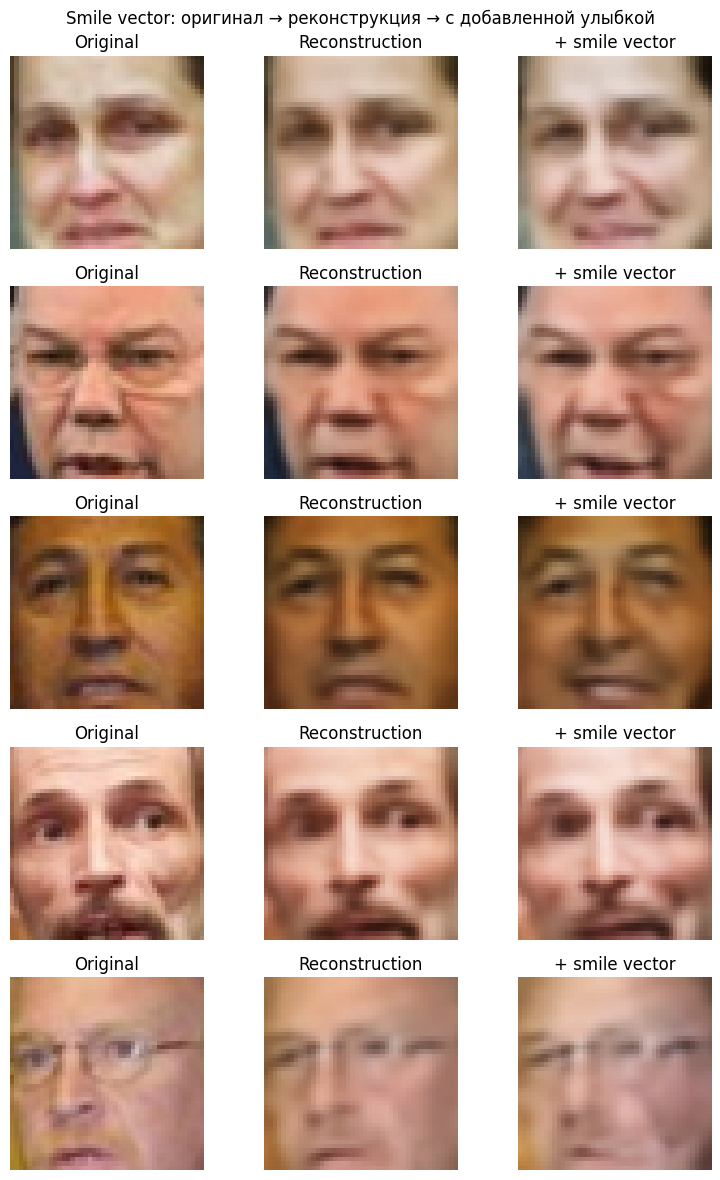

In [14]:
# Используем колонку 'Smiling' из lfw_attributes: > 0.5 — улыбается, < -0.5 — точно не улыбается.
smile_score = attrs_train["Smiling"].astype(float).values
smile_mask = smile_score > 0.5
nosmile_mask = smile_score < -0.5
N_PER_GROUP = 20

smile_idx = np.where(smile_mask)[0][:N_PER_GROUP]
nosmile_idx = np.where(nosmile_mask)[0][:N_PER_GROUP]
print(f"Используем {len(smile_idx)} улыбающихся и {len(nosmile_idx)} не улыбающихся лиц.")

ae.train(mode=False)
with torch.no_grad():
    z_smile = ae.encoder(X_train_t[smile_idx].to(device))
    z_nosmile = ae.encoder(X_train_t[nosmile_idx].to(device))

smile_vec = z_smile.mean(dim=0) - z_nosmile.mean(dim=0)
print("smile_vec norm:", float(smile_vec.norm()))

# Применяем к 5 грустным лицам из train (Smiling < -0.5).
sad_idx = np.where(nosmile_mask)[0][N_PER_GROUP:N_PER_GROUP + 5]
with torch.no_grad():
    sad_imgs = X_train_t[sad_idx].to(device)
    z_sad = ae.encoder(sad_imgs)
    z_sad_smile = z_sad + smile_vec
    recon_sad = ae.decoder(z_sad)
    recon_smile = ae.decoder(z_sad_smile)

fig, axes = plt.subplots(5, 3, figsize=(8, 12))
for i in range(5):
    axes[i, 0].imshow(sad_imgs[i].cpu().numpy().transpose(1, 2, 0))
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(np.clip(recon_sad[i].cpu().numpy().transpose(1, 2, 0), 0, 1))
    axes[i, 1].set_title("Reconstruction")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(np.clip(recon_smile[i].cpu().numpy().transpose(1, 2, 0), 0, 1))
    axes[i, 2].set_title("+ smile vector")
    axes[i, 2].axis("off")
plt.suptitle("Smile vector: оригинал → реконструкция → с добавленной улыбкой")
plt.tight_layout(); plt.show()


**Ответ про smile vector.** Линейная арифметика в латенте работает потому, что AE неявно выучил semantically meaningful directions: атрибут «улыбка» соответствует приблизительно линейному направлению в latent space. Усреднение по 20 примерам каждого класса гасит индивидуальные различия (черты лица, прическу, освещение) и оставляет именно атрибут улыбки. Прибавление этого вектора к латенту грустного лица сдвигает декодированную картинку в сторону «улыбающейся» моды — человек тот же, но с улыбкой. Этот же приём (latent-space arithmetic) лежит в основе классической работы Mikolov с word2vec и многих последующих рекомендательных и генеративных систем.

## Часть 2. Variational Autoencoder (10 баллов)

Обучим VAE на MNIST: encoder выдаёт `(mu, logsigma)` для каждого изображения, decoder восстанавливает картинку. Loss = BCE (reconstruction) + KL(q(z|x) || N(0, I)).

### 2.1 Архитектура и обучение VAE (2 балла)

**Конвенция:** сетка возвращает `logsigma = log(sigma^2)`. Тогда:
- reparameterization: `std = exp(0.5 * logsigma); z = mu + std * eps`
- KL: `-0.5 * sum(1 + logsigma - mu^2 - exp(logsigma))` — точно по формуле из задания

**Все суммы — sum, а не mean** (это важно: и BCE с `reduction='sum'`, и KL через `torch.sum`).

In [15]:
BATCH_VAE = 128
mnist_train = datasets.MNIST(
    root="mnist_data/", train=True, transform=transforms.ToTensor(), download=True
)
mnist_test = datasets.MNIST(
    root="mnist_data/", train=False, transform=transforms.ToTensor(), download=True
)
train_loader_vae = DataLoader(mnist_train, batch_size=BATCH_VAE, shuffle=True)
test_loader_vae = DataLoader(mnist_test, batch_size=BATCH_VAE, shuffle=False)
print("MNIST train:", len(mnist_train), "| test:", len(mnist_test))



  0%|          | 0.00/9.91M [00:00<?, ?B/s]


  0%|          | 32.8k/9.91M [00:00<00:35, 275kB/s]


  1%|          | 98.3k/9.91M [00:00<00:30, 319kB/s]


  2%|▏         | 197k/9.91M [00:00<00:23, 415kB/s] 


  4%|▎         | 360k/9.91M [00:00<00:16, 595kB/s]

...


 97%|█████████▋| 1.61M/1.65M [00:01<00:00, 1.05MB/s]


100%|██████████| 1.65M/1.65M [00:01<00:00, 984kB/s] 


  0%|          | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 1.01MB/s]

MNIST train: 60000 | test: 10000


In [16]:
class VAE(nn.Module):
    """Свёрточный VAE для MNIST 1×28×28 -> latent_dim -> 1×28×28."""

    def __init__(self, latent_dim: int = 32):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(inplace=True),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logsigma = nn.Linear(64 * 7 * 7, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7 -> 14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # 14 -> 28
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Возвращает (mu, logsigma), где logsigma = log(sigma^2)."""
        h = self.encoder_conv(x)
        return self.fc_mu(h), self.fc_logsigma(h)

    def gaussian_sampler(self, mu: torch.Tensor, logsigma: torch.Tensor) -> torch.Tensor:
        """Reparameterization trick. На инференсе возвращаем mu (без шума)."""
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        h = self.decoder_fc(z)
        h = h.view(-1, 64, 7, 7)
        return self.decoder_conv(h)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        recon = self.decode(z)
        return mu, logsigma, recon


In [17]:
def KL_divergence(mu: torch.Tensor, logsigma: torch.Tensor) -> torch.Tensor:
    """D_KL(q(z|x) || N(0, I)) с конвенцией logsigma = log(sigma^2)."""
    return -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())


def log_likelihood(x: torch.Tensor, reconstruction: torch.Tensor) -> torch.Tensor:
    """BCE с reduction='sum' — соответствует логарифму правдоподобия Бернулли."""
    return F.binary_cross_entropy(reconstruction, x, reduction="sum")


def loss_vae(x: torch.Tensor, mu: torch.Tensor, logsigma: torch.Tensor,
             reconstruction: torch.Tensor) -> torch.Tensor:
    """ELBO: KL + reconstruction. Знак — как в формуле задания."""
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)


# Sanity-check VAE
_vae_test = VAE(latent_dim=32)
_dummy = torch.randn(4, 1, 28, 28).abs().clamp(0, 1)
_mu, _ls, _rec = _vae_test(_dummy)
assert _mu.shape == (4, 32) and _ls.shape == (4, 32), f"{_mu.shape} {_ls.shape}"
assert _rec.shape == (4, 1, 28, 28), f"{_rec.shape}"
_l = loss_vae(_dummy, _mu, _ls, _rec)
print("Sanity-check VAE OK. recon:", tuple(_rec.shape), "| loss:", float(_l))
del _vae_test, _dummy, _mu, _ls, _rec, _l


Sanity-check VAE OK. recon: (4, 1, 28, 28) | loss: 2135.512939453125


/var/folders/13/pqnv3b791_l1507lm67lcx6h0000gn/T/ipykernel_37104/1758900266.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print("Sanity-check VAE OK. recon:", tuple(_rec.shape), "| loss:", float(_l))


In [18]:
LATENT_DIM_VAE = 32
EPOCHS_VAE = 15

vae = VAE(latent_dim=LATENT_DIM_VAE).to(device)
optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)

vae_train_losses, vae_test_losses = [], []

for epoch in range(1, EPOCHS_VAE + 1):
    vae.train()
    sum_train, n_train = 0.0, 0
    for xb, _ in train_loader_vae:
        xb = xb.to(device)
        mu, logsigma, recon = vae(xb)
        loss = loss_vae(xb, mu, logsigma, recon)
        optimizer_vae.zero_grad()
        loss.backward()
        optimizer_vae.step()
        sum_train += loss.item()
        n_train += xb.size(0)
    train_loss = sum_train / n_train

    vae.train(mode=False)
    sum_test, n_test = 0.0, 0
    with torch.no_grad():
        for xb, _ in test_loader_vae:
            xb = xb.to(device)
            mu, logsigma, recon = vae(xb)
            sum_test += loss_vae(xb, mu, logsigma, recon).item()
            n_test += xb.size(0)
    test_loss = sum_test / n_test

    vae_train_losses.append(train_loss)
    vae_test_losses.append(test_loss)
    print(f"VAE Epoch {epoch:02d}/{EPOCHS_VAE} | train ELBO/img = {train_loss:.3f} | test ELBO/img = {test_loss:.3f}")

print(f"VAE финальный test ELBO/img = {vae_test_losses[-1]:.3f}")


VAE Epoch 01/15 | train ELBO/img = 161.094 | test ELBO/img = 107.705


VAE Epoch 02/15 | train ELBO/img = 117.780 | test ELBO/img = 99.876


VAE Epoch 03/15 | train ELBO/img = 112.925 | test ELBO/img = 98.291


VAE Epoch 04/15 | train ELBO/img = 110.230 | test ELBO/img = 97.188


VAE Epoch 05/15 | train ELBO/img = 108.589 | test ELBO/img = 94.633


...

VAE Epoch 11/15 | train ELBO/img = 104.977 | test ELBO/img = 92.176


VAE Epoch 12/15 | train ELBO/img = 104.634 | test ELBO/img = 92.884


VAE Epoch 13/15 | train ELBO/img = 104.348 | test ELBO/img = 92.477


VAE Epoch 14/15 | train ELBO/img = 104.139 | test ELBO/img = 92.629


VAE Epoch 15/15 | train ELBO/img = 103.907 | test ELBO/img = 92.128
VAE финальный test ELBO/img = 92.128


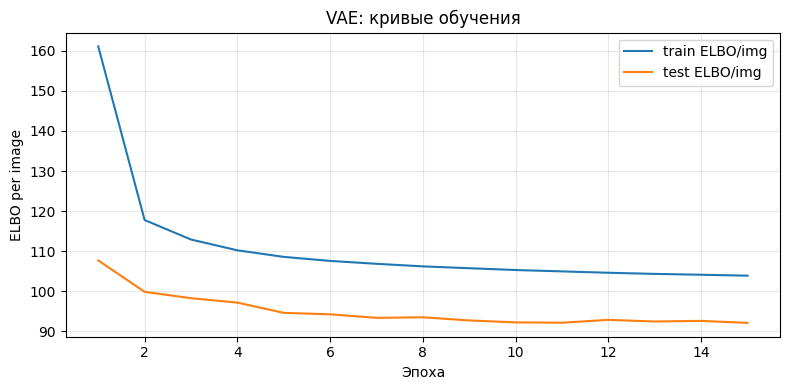

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS_VAE + 1), vae_train_losses, label="train ELBO/img")
plt.plot(range(1, EPOCHS_VAE + 1), vae_test_losses, label="test ELBO/img")
plt.xlabel("Эпоха"); plt.ylabel("ELBO per image")
plt.title("VAE: кривые обучения"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


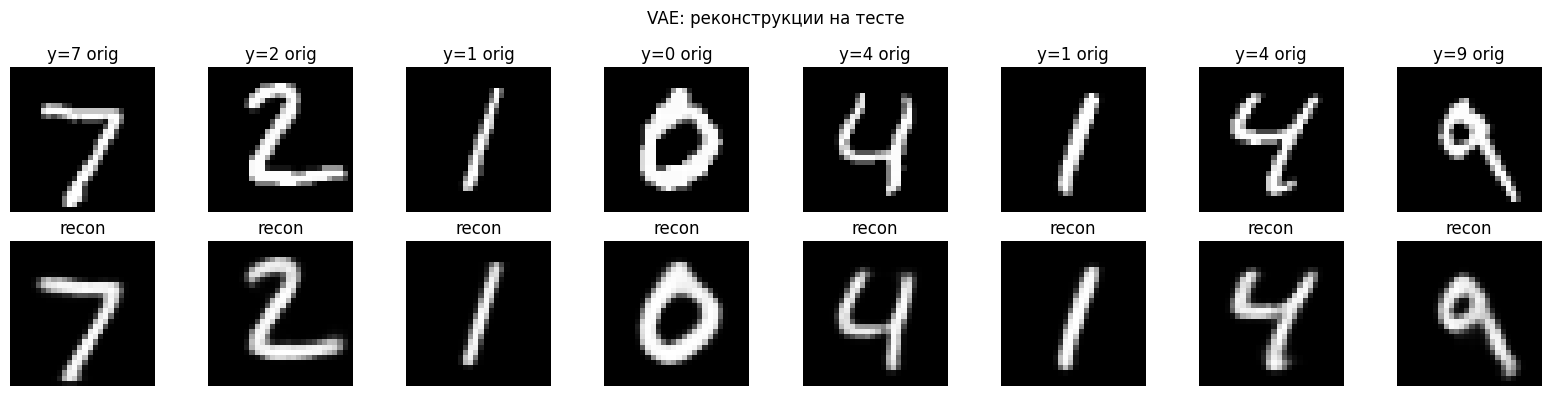

In [20]:
# Визуализация реконструкций VAE на тесте
vae.train(mode=False)
test_iter = iter(test_loader_vae)
xb, yb = next(test_iter)
N_SHOW = 8
with torch.no_grad():
    mu, logsigma, recon = vae(xb[:N_SHOW].to(device))
    recon_np = recon.cpu().numpy().squeeze(1)
    orig_np = xb[:N_SHOW].numpy().squeeze(1)

fig, axes = plt.subplots(2, N_SHOW, figsize=(2 * N_SHOW, 4))
for i in range(N_SHOW):
    axes[0, i].imshow(orig_np[i], cmap="gray")
    axes[0, i].set_title(f"y={int(yb[i])} orig"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_np[i], cmap="gray")
    axes[1, i].set_title("recon"); axes[1, i].axis("off")
plt.suptitle("VAE: реконструкции на тесте"); plt.tight_layout(); plt.show()


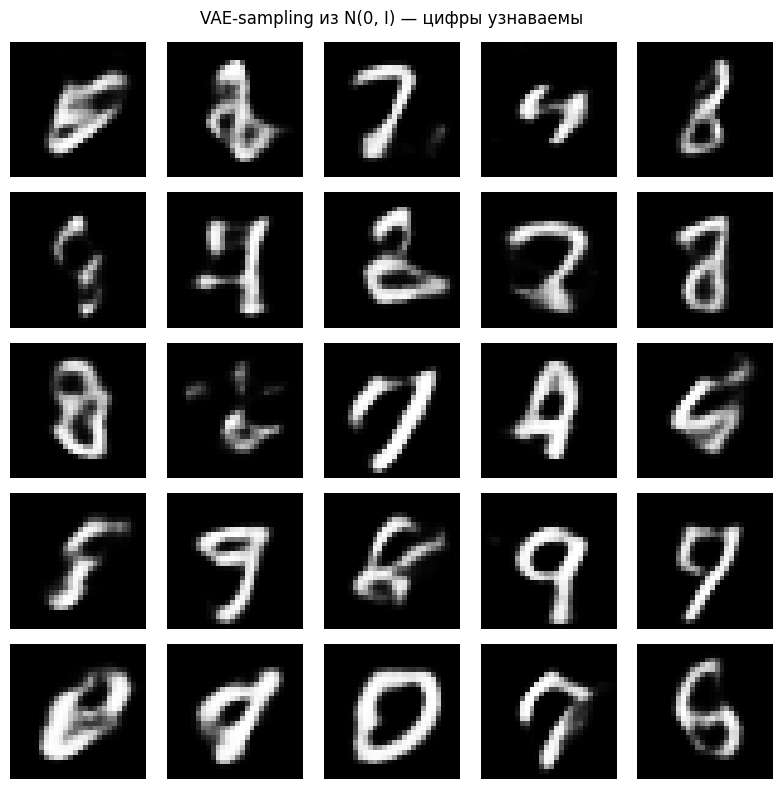

In [21]:
# Sampling из N(0, I) — в VAE это работает, потому что KL стянул q(z|x) к N(0, I).
vae.train(mode=False)
with torch.no_grad():
    z_n01 = torch.randn(25, LATENT_DIM_VAE, device=device)
    gen = vae.decode(z_n01).cpu().numpy().squeeze(1)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(gen[i], cmap="gray"); ax.axis("off")
plt.suptitle("VAE-sampling из N(0, I) — цифры узнаваемы")
plt.tight_layout(); plt.show()


**Сравнение с AE.** В отличие от обычного AE (где sampling из `N(0, 1)` давал мусор), VAE генерирует осмысленные цифры прямо из стандартного нормального. Это прямое следствие KL-регуляризации в loss'е — она «штрафует» сетку, если апостериор `q(z|x)` сильно расходится с прайером `N(0, I)`, и поэтому в обученном пространстве реалистичные точки концентрируются вокруг 0 с дисперсией 1.

### 2.2 TSNE латентного пространства VAE (2 балла)

Латенты test: (10000, 32) | метки: (10000,)
Считаем TSNE на 5000 точках...


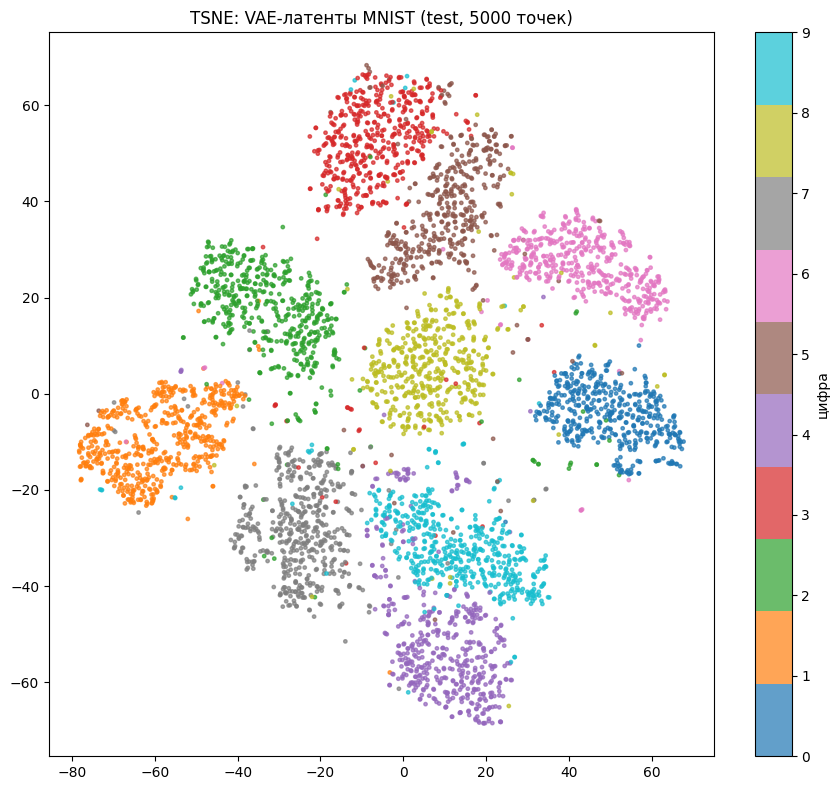

In [22]:
# Сбор mu для всего test_loader_vae
vae.train(mode=False)
all_mus, all_ys = [], []
with torch.no_grad():
    for xb, yb in test_loader_vae:
        xb = xb.to(device)
        mu, _ = vae.encode(xb)
        all_mus.append(mu.cpu())
        all_ys.append(yb)
all_mus = torch.cat(all_mus, dim=0).numpy()
all_ys = torch.cat(all_ys, dim=0).numpy()
print("Латенты test:", all_mus.shape, "| метки:", all_ys.shape)

# TSNE на первых 5000 — компромисс между качеством и временем.
N_TSNE = 5000
print("Считаем TSNE на", N_TSNE, "точках...")
tsne_emb = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(
    all_mus[:N_TSNE]
)

plt.figure(figsize=(9, 8))
scatter = plt.scatter(tsne_emb[:, 0], tsne_emb[:, 1], c=all_ys[:N_TSNE], cmap="tab10", s=6, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="цифра")
plt.title(f"TSNE: VAE-латенты MNIST (test, {N_TSNE} точек)")
plt.tight_layout(); plt.show()


**Ответ.** TSNE-визуализация показывает 10 кластеров, соответствующих 10 классам цифр — VAE неявно выучил классовую структуру через визуальное сходство, хотя метки `y` ему ни разу не показывали. Перекрытия между кластерами видны для визуально похожих цифр (4/9, 3/8, 5/6) — это ожидаемо. KL-регуляризация стянула все кластеры к одному центру, поэтому они компактны и плотно прилегают друг к другу (в отличие от AE, где кластеры разъезжались бы по всему пространству). Получается, что VAE «бесплатно» решает задачу неконтролируемой кластеризации как побочный эффект reconstruction-задачи.

### 2.3 Conditional VAE (6 баллов)

В CVAE мы передаём метку класса как одноразовое (one-hot) представление и конкатенируем его со входом encoder'а и decoder'а. Тогда латентное `z` отвечает только за стиль (наклон, толщина), а класс — за «какую цифру рисовать».

In [23]:
class CVAE(nn.Module):
    """FC CVAE для MNIST. Conditioning через one-hot в encoder и decoder."""

    def __init__(self, num_classes: int = 10, latent_dim: int = 20):
        super().__init__()
        self.num_classes = num_classes
        self.latent_dim = latent_dim

        # Encoder: [x_flat (784) | y_oh (10)] -> 400 -> (mu, logsigma)
        self.fc_enc = nn.Linear(784 + num_classes, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logsigma = nn.Linear(400, latent_dim)

        # Decoder: [z (latent_dim) | y_oh (10)] -> 400 -> 784
        self.fc_dec1 = nn.Linear(latent_dim + num_classes, 400)
        self.fc_dec2 = nn.Linear(400, 784)

    def encode(self, x: torch.Tensor, y_oh: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x_flat = x.view(x.size(0), -1)
        h = F.relu(self.fc_enc(torch.cat([x_flat, y_oh], dim=1)))
        return self.fc_mu(h), self.fc_logsigma(h)

    def gaussian_sampler(self, mu: torch.Tensor, logsigma: torch.Tensor) -> torch.Tensor:
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + std * eps
        return mu

    def decode(self, z: torch.Tensor, y_oh: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.fc_dec1(torch.cat([z, y_oh], dim=1)))
        x_flat = torch.sigmoid(self.fc_dec2(h))
        return x_flat.view(-1, 1, 28, 28)

    def forward(self, x: torch.Tensor, y_oh: torch.Tensor):
        mu, logsigma = self.encode(x, y_oh)
        z = self.gaussian_sampler(mu, logsigma)
        recon = self.decode(z, y_oh)
        return mu, logsigma, recon


# Sanity-check CVAE
_cvae_test = CVAE()
_dummy_x = torch.rand(4, 1, 28, 28)
_dummy_y = F.one_hot(torch.tensor([1, 2, 3, 4]), num_classes=10).float()
_mu, _ls, _rec = _cvae_test(_dummy_x, _dummy_y)
assert _rec.shape == (4, 1, 28, 28) and _mu.shape == (4, 20), f"{_rec.shape} {_mu.shape}"
print("Sanity-check CVAE OK. recon:", tuple(_rec.shape), "| mu:", tuple(_mu.shape))
del _cvae_test, _dummy_x, _dummy_y, _mu, _ls, _rec


Sanity-check CVAE OK. recon: (4, 1, 28, 28) | mu: (4, 20)


In [24]:
LATENT_DIM_CVAE = 20
EPOCHS_CVAE = 20

cvae = CVAE(num_classes=10, latent_dim=LATENT_DIM_CVAE).to(device)
optimizer_cvae = optim.Adam(cvae.parameters(), lr=1e-3)

cvae_train_losses, cvae_test_losses = [], []

for epoch in range(1, EPOCHS_CVAE + 1):
    cvae.train()
    sum_train, n_train = 0.0, 0
    for xb, yb in train_loader_vae:
        xb = xb.to(device)
        y_oh = F.one_hot(yb, num_classes=10).float().to(device)
        mu, logsigma, recon = cvae(xb, y_oh)
        loss = loss_vae(xb, mu, logsigma, recon)
        optimizer_cvae.zero_grad()
        loss.backward()
        optimizer_cvae.step()
        sum_train += loss.item()
        n_train += xb.size(0)
    train_loss = sum_train / n_train

    cvae.train(mode=False)
    sum_test, n_test = 0.0, 0
    with torch.no_grad():
        for xb, yb in test_loader_vae:
            xb = xb.to(device)
            y_oh = F.one_hot(yb, num_classes=10).float().to(device)
            mu, logsigma, recon = cvae(xb, y_oh)
            sum_test += loss_vae(xb, mu, logsigma, recon).item()
            n_test += xb.size(0)
    test_loss = sum_test / n_test

    cvae_train_losses.append(train_loss)
    cvae_test_losses.append(test_loss)
    print(f"CVAE Epoch {epoch:02d}/{EPOCHS_CVAE} | train ELBO/img = {train_loss:.3f} | test ELBO/img = {test_loss:.3f}")

print(f"CVAE финальный test ELBO/img = {cvae_test_losses[-1]:.3f}")


CVAE Epoch 01/20 | train ELBO/img = 163.130 | test ELBO/img = 117.871


CVAE Epoch 02/20 | train ELBO/img = 119.751 | test ELBO/img = 105.405


CVAE Epoch 03/20 | train ELBO/img = 112.327 | test ELBO/img = 101.169


CVAE Epoch 04/20 | train ELBO/img = 109.000 | test ELBO/img = 98.368


CVAE Epoch 05/20 | train ELBO/img = 106.935 | test ELBO/img = 97.095


...

CVAE Epoch 16/20 | train ELBO/img = 100.433 | test ELBO/img = 91.842


CVAE Epoch 17/20 | train ELBO/img = 100.220 | test ELBO/img = 92.198


CVAE Epoch 18/20 | train ELBO/img = 100.011 | test ELBO/img = 91.037


CVAE Epoch 19/20 | train ELBO/img = 99.831 | test ELBO/img = 91.100


CVAE Epoch 20/20 | train ELBO/img = 99.679 | test ELBO/img = 91.734
CVAE финальный test ELBO/img = 91.734


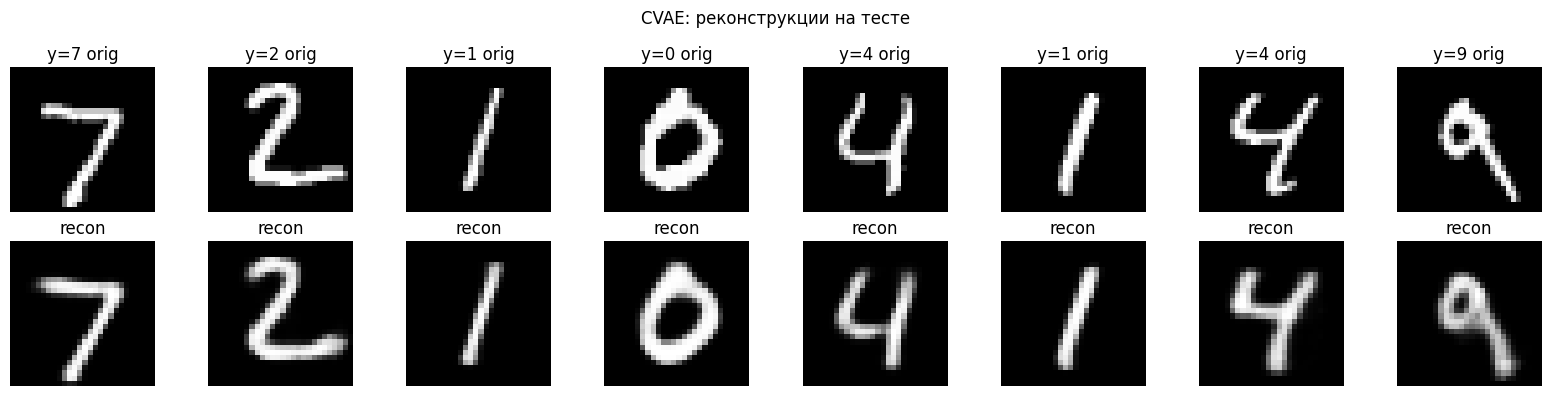

In [25]:
# Реконструкции CVAE с правильной меткой
cvae.train(mode=False)
xb, yb = next(iter(test_loader_vae))
N_SHOW = 8
with torch.no_grad():
    y_oh = F.one_hot(yb[:N_SHOW], num_classes=10).float().to(device)
    _, _, recon = cvae(xb[:N_SHOW].to(device), y_oh)
    recon_np = recon.cpu().numpy().squeeze(1)
    orig_np = xb[:N_SHOW].numpy().squeeze(1)

fig, axes = plt.subplots(2, N_SHOW, figsize=(2 * N_SHOW, 4))
for i in range(N_SHOW):
    axes[0, i].imshow(orig_np[i], cmap="gray")
    axes[0, i].set_title(f"y={int(yb[i])} orig"); axes[0, i].axis("off")
    axes[1, i].imshow(recon_np[i], cmap="gray")
    axes[1, i].set_title("recon"); axes[1, i].axis("off")
plt.suptitle("CVAE: реконструкции на тесте")
plt.tight_layout(); plt.show()


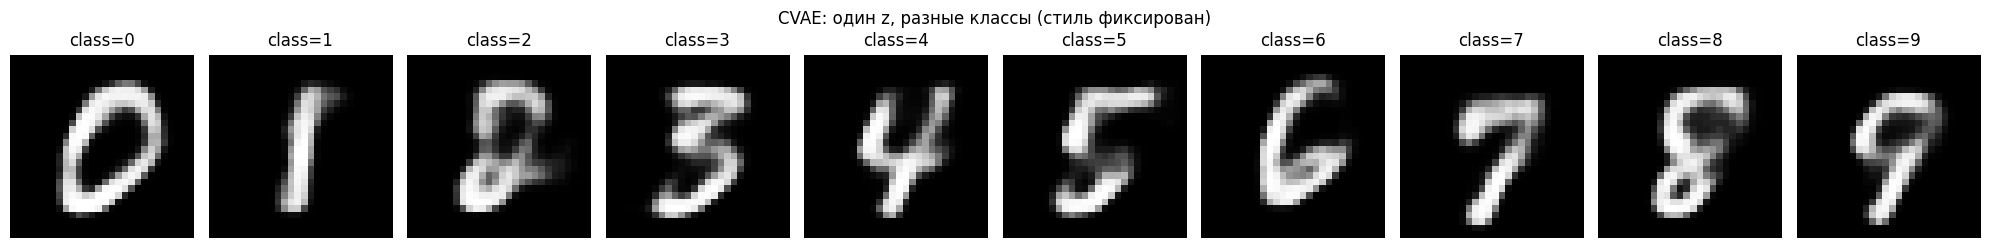

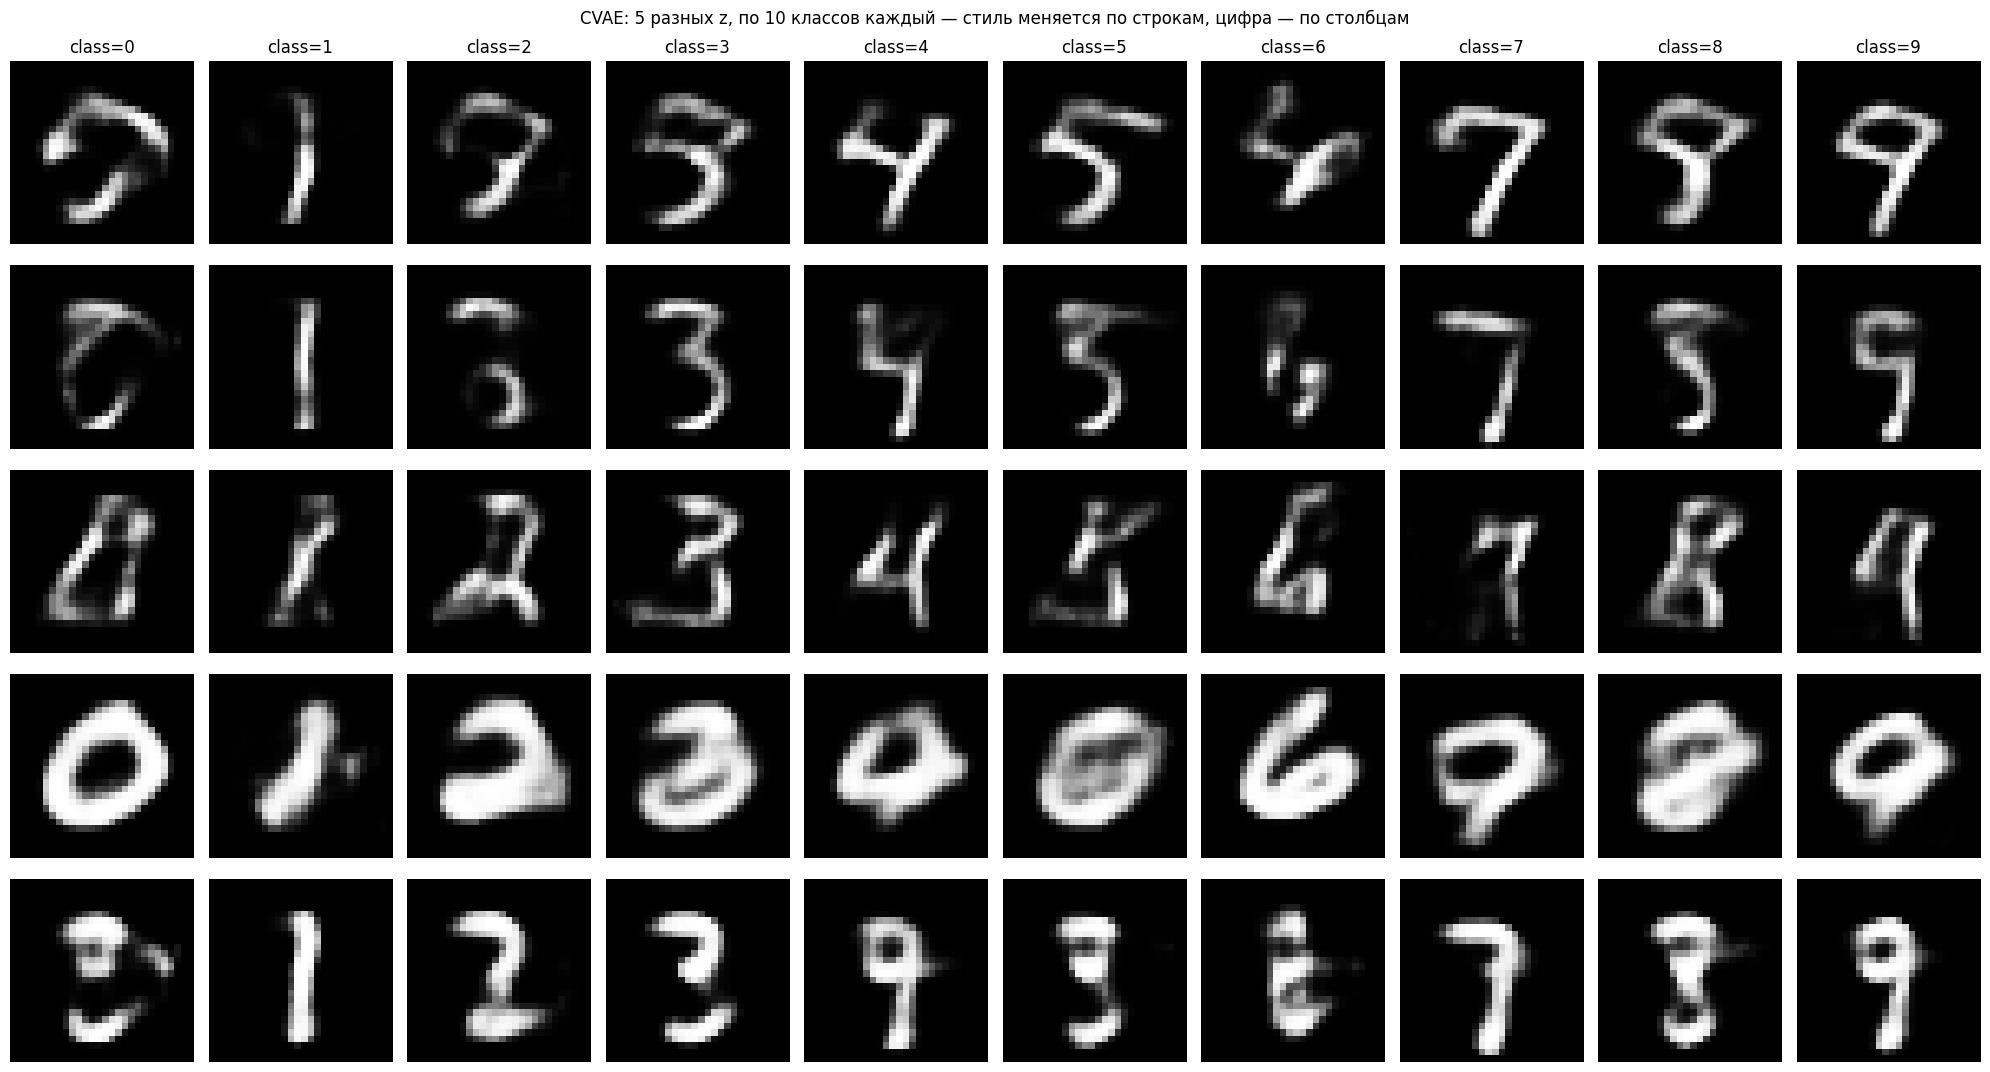

In [26]:
# Sampling: один и тот же z, разные классы — должны получиться 10 цифр в одном "стиле".
cvae.train(mode=False)
with torch.no_grad():
    z_single = torch.randn(1, LATENT_DIM_CVAE, device=device).repeat(10, 1)
    y_all = F.one_hot(torch.arange(10), num_classes=10).float().to(device)
    gen = cvae.decode(z_single, y_all).cpu().numpy().squeeze(1)

fig, axes = plt.subplots(1, 10, figsize=(20, 2.5))
for i in range(10):
    axes[i].imshow(gen[i], cmap="gray")
    axes[i].set_title(f"class={i}")
    axes[i].axis("off")
plt.suptitle("CVAE: один z, разные классы (стиль фиксирован)")
plt.tight_layout(); plt.show()

# Ещё несколько разных z для разнообразия
fig, axes = plt.subplots(5, 10, figsize=(20, 11))
with torch.no_grad():
    for row in range(5):
        z_single = torch.randn(1, LATENT_DIM_CVAE, device=device).repeat(10, 1)
        gen = cvae.decode(z_single, y_all).cpu().numpy().squeeze(1)
        for col in range(10):
            axes[row, col].imshow(gen[col], cmap="gray")
            if row == 0:
                axes[row, col].set_title(f"class={col}")
            axes[row, col].axis("off")
plt.suptitle("CVAE: 5 разных z, по 10 классов каждый — стиль меняется по строкам, цифра — по столбцам")
plt.tight_layout(); plt.show()


Считаем TSNE для CVAE-латентов...


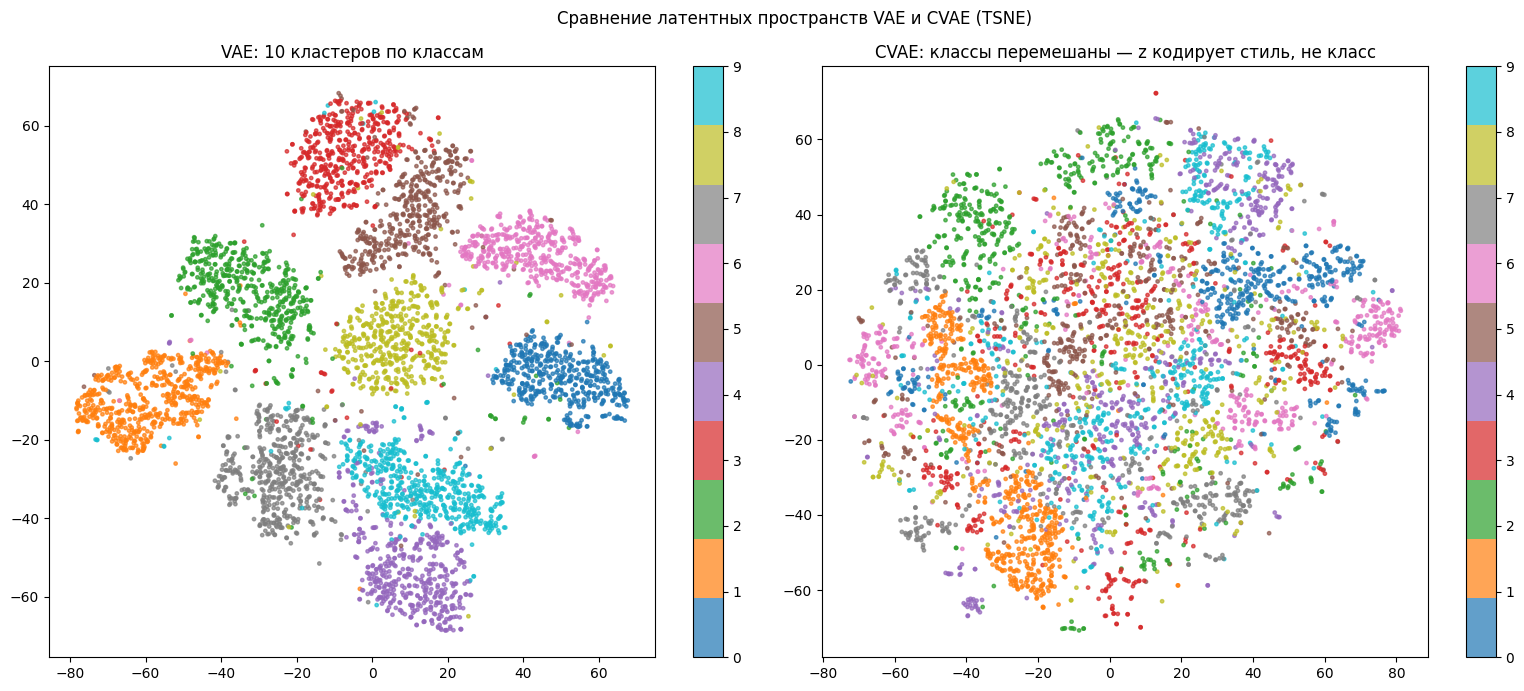

In [27]:
# TSNE для CVAE-латентов — для контраста с VAE.
cvae.train(mode=False)
all_mus_c, all_ys_c = [], []
with torch.no_grad():
    for xb, yb in test_loader_vae:
        xb = xb.to(device)
        y_oh = F.one_hot(yb, num_classes=10).float().to(device)
        mu, _ = cvae.encode(xb, y_oh)
        all_mus_c.append(mu.cpu())
        all_ys_c.append(yb)
all_mus_c = torch.cat(all_mus_c, dim=0).numpy()
all_ys_c = torch.cat(all_ys_c, dim=0).numpy()

N_TSNE = 5000
print("Считаем TSNE для CVAE-латентов...")
tsne_emb_c = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(
    all_mus_c[:N_TSNE]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sc1 = axes[0].scatter(tsne_emb[:, 0], tsne_emb[:, 1], c=all_ys[:N_TSNE], cmap="tab10", s=6, alpha=0.7)
axes[0].set_title("VAE: 10 кластеров по классам")
plt.colorbar(sc1, ax=axes[0], ticks=range(10))

sc2 = axes[1].scatter(tsne_emb_c[:, 0], tsne_emb_c[:, 1], c=all_ys_c[:N_TSNE], cmap="tab10", s=6, alpha=0.7)
axes[1].set_title("CVAE: классы перемешаны — z кодирует стиль, не класс")
plt.colorbar(sc2, ax=axes[1], ticks=range(10))

plt.suptitle("Сравнение латентных пространств VAE и CVAE (TSNE)")
plt.tight_layout(); plt.show()


**Сравнение VAE vs CVAE.** В CVAE кластеры классов размыты и перемешаны (классовая раскраска не образует чётких островов в TSNE), в отличие от VAE, где TSNE рисует 10 хорошо разделённых пятен.

Это ожидаемо: класс уже передан через условие (one-hot), и нейросети нет смысла кодировать его ещё и в `z`. Латентный код `z` берёт на себя только то, что осталось — «стиль» написания (наклон, толщина, размер штриха).

Это подтверждается экспериментом «один `z`, разные классы»: одна «натура» (один сэмпл `z`) даёт визуально консистентные цифры разных классов — они написаны как будто одним почерком. Это и есть желаемое разделение role'й между латентом и условием, которое делает CVAE удобным инструментом для контролируемой генерации.

## BONUS 1. Denoising Autoencoder (2 балла)

Обучаем свёрточный AE на парах `(noisy, clean)` — он учится удалять гауссовский шум.

In [28]:
class DenoisingAE(nn.Module):
    """Свёрточный AE 1×28×28 -> 64 -> 1×28×28 (без KL, без mu/logsigma)."""

    def __init__(self, latent_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7), nn.ReLU(inplace=True),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 3, 2, 1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


EPOCHS_DAE = 12
NOISE_FACTOR = 0.5

dae = DenoisingAE(latent_dim=64).to(device)
optimizer_dae = optim.Adam(dae.parameters(), lr=1e-3)

dae_train_losses, dae_test_losses = [], []

for epoch in range(1, EPOCHS_DAE + 1):
    dae.train()
    sum_train, n_train = 0.0, 0
    for xb, _ in train_loader_vae:
        xb = xb.to(device)
        noisy = torch.clamp(xb + NOISE_FACTOR * torch.randn_like(xb), 0.0, 1.0)
        denoised = dae(noisy)
        loss = F.mse_loss(denoised, xb)
        optimizer_dae.zero_grad()
        loss.backward()
        optimizer_dae.step()
        sum_train += loss.item() * xb.size(0)
        n_train += xb.size(0)
    train_loss = sum_train / n_train

    dae.train(mode=False)
    sum_test, n_test = 0.0, 0
    with torch.no_grad():
        for xb, _ in test_loader_vae:
            xb = xb.to(device)
            noisy = torch.clamp(xb + NOISE_FACTOR * torch.randn_like(xb), 0.0, 1.0)
            denoised = dae(noisy)
            sum_test += F.mse_loss(denoised, xb).item() * xb.size(0)
            n_test += xb.size(0)
    test_loss = sum_test / n_test

    dae_train_losses.append(train_loss)
    dae_test_losses.append(test_loss)
    print(f"DAE Epoch {epoch:02d}/{EPOCHS_DAE} | train MSE = {train_loss:.5f} | test MSE = {test_loss:.5f}")

print(f"DAE финальный test MSE = {dae_test_losses[-1]:.5f}")


DAE Epoch 01/12 | train MSE = 0.04123 | test MSE = 0.01687


DAE Epoch 02/12 | train MSE = 0.01495 | test MSE = 0.01338


DAE Epoch 03/12 | train MSE = 0.01277 | test MSE = 0.01212


DAE Epoch 04/12 | train MSE = 0.01188 | test MSE = 0.01150


DAE Epoch 05/12 | train MSE = 0.01138 | test MSE = 0.01103


...

DAE Epoch 08/12 | train MSE = 0.01064 | test MSE = 0.01047


DAE Epoch 09/12 | train MSE = 0.01049 | test MSE = 0.01040


DAE Epoch 10/12 | train MSE = 0.01036 | test MSE = 0.01029


DAE Epoch 11/12 | train MSE = 0.01027 | test MSE = 0.01019


DAE Epoch 12/12 | train MSE = 0.01017 | test MSE = 0.01007
DAE финальный test MSE = 0.01007


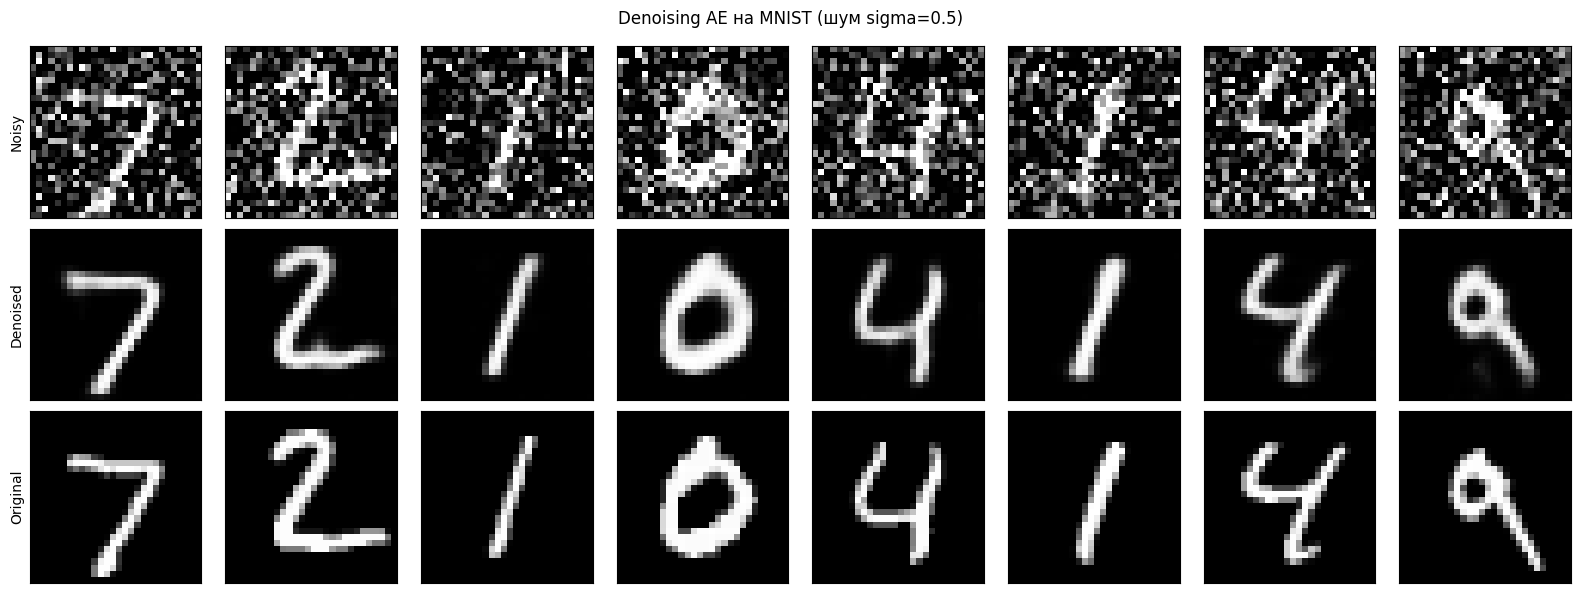

In [29]:
# Визуализация: noisy | denoised | original.
dae.train(mode=False)
xb, _ = next(iter(test_loader_vae))
N_SHOW = 8
with torch.no_grad():
    clean = xb[:N_SHOW].to(device)
    noisy = torch.clamp(clean + NOISE_FACTOR * torch.randn_like(clean), 0.0, 1.0)
    denoised = dae(noisy)

fig, axes = plt.subplots(3, N_SHOW, figsize=(2 * N_SHOW, 6))
for i in range(N_SHOW):
    axes[0, i].imshow(noisy[i, 0].cpu(), cmap="gray")
    if i == 0: axes[0, i].set_ylabel("Noisy")
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    axes[1, i].imshow(denoised[i, 0].cpu(), cmap="gray")
    if i == 0: axes[1, i].set_ylabel("Denoised")
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    axes[2, i].imshow(clean[i, 0].cpu(), cmap="gray")
    if i == 0: axes[2, i].set_ylabel("Original")
    axes[2, i].set_xticks([]); axes[2, i].set_yticks([])
plt.suptitle(f"Denoising AE на MNIST (шум sigma={NOISE_FACTOR})")
plt.tight_layout(); plt.show()


## BONUS 2. Image Retrieval на LFW (2 балла)

Используем AE из Части 1 (его латенты для retrieval работают лучше, чем у VAE: VAE-латенты «сжаты» KL-регуляризацией к N(0, I) — теряется специфика конкретных лиц).

Латенты train: (11828, 256)
Пример 1: первое лицо из val


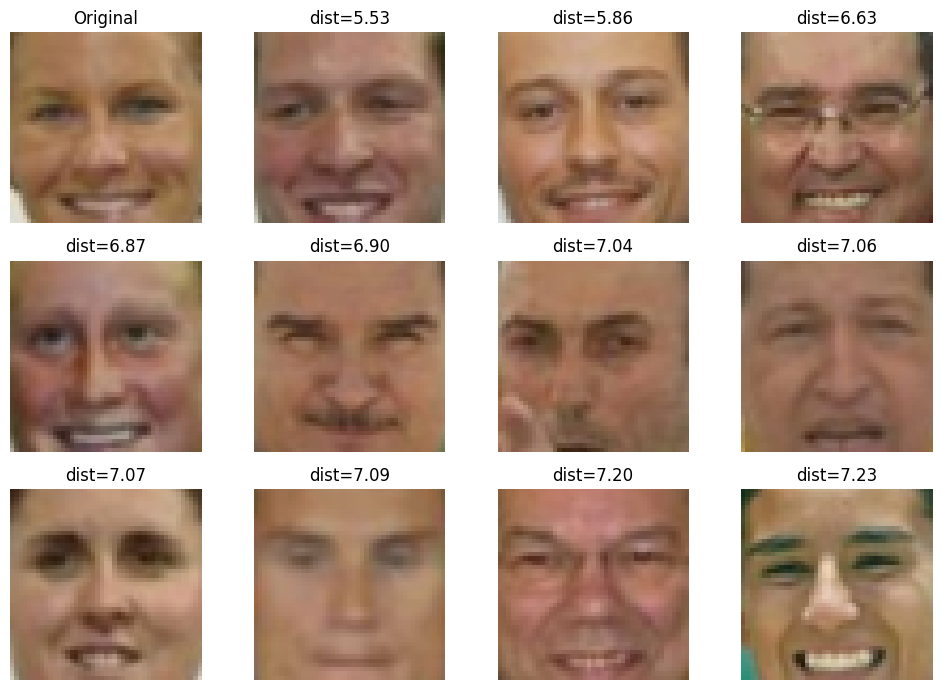

Пример 2: третье лицо из val


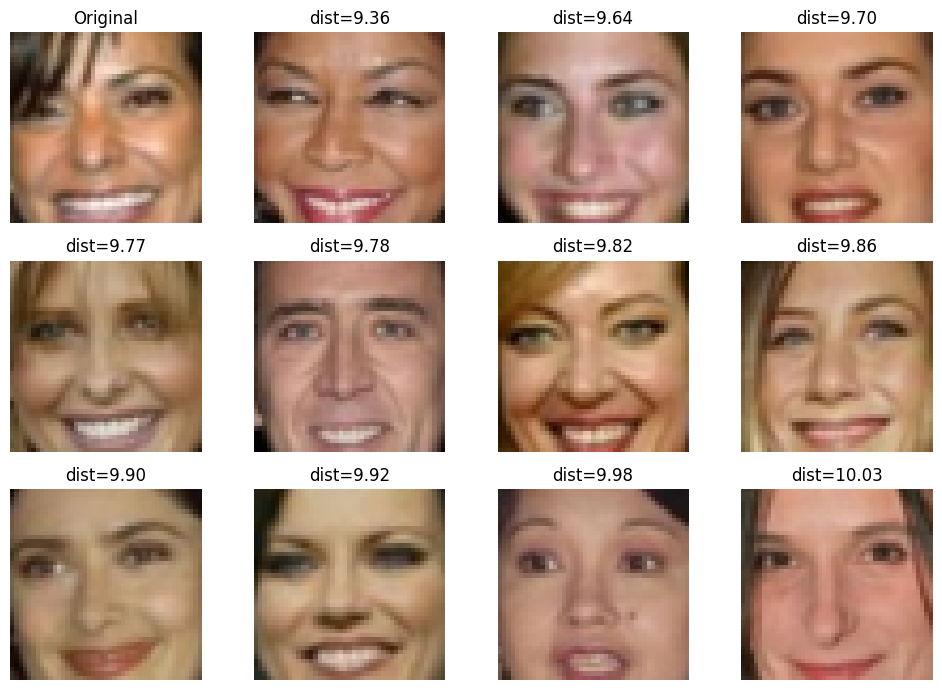

In [30]:
# Получаем латенты всех train-лиц через AE.
ae.train(mode=False)
all_codes = []
with torch.no_grad():
    for (xb,) in DataLoader(TensorDataset(X_train_t), batch_size=128, shuffle=False):
        xb = xb.to(device)
        _, z = ae(xb)
        all_codes.append(z.cpu().numpy())
all_codes = np.concatenate(all_codes, axis=0)
print("Латенты train:", all_codes.shape)

# Заметка: sklearn.neighbors.LSHForest УДАЛЁН из sklearn 0.21+, поэтому используем
# NearestNeighbors с ball_tree — для нашего N≈12k это работает за миллисекунды.
nn_model = NearestNeighbors(n_neighbors=11, algorithm="ball_tree", metric="euclidean").fit(all_codes)


def get_similar(image: torch.Tensor, n_neighbors: int = 5):
    """image: тензор (3, 45, 45). Возвращает (distances, neighbors_tensor)."""
    ae.train(mode=False)
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        _, code = ae(x)
    distances, indices = nn_model.kneighbors(code.cpu().numpy(), n_neighbors=n_neighbors)
    return distances[0], X_train_t[indices[0]]


def show_similar(image: torch.Tensor):
    """Визуализация: оригинал + 11 ближайших соседей."""
    distances, neighbors = get_similar(image, n_neighbors=11)
    plt.figure(figsize=(10, 7))
    plt.subplot(3, 4, 1)
    plt.imshow(image.cpu().numpy().transpose(1, 2, 0))
    plt.title("Original")
    plt.axis("off")
    for i in range(11):
        plt.subplot(3, 4, i + 2)
        plt.imshow(neighbors[i].cpu().numpy().transpose(1, 2, 0))
        plt.title(f"dist={distances[i]:.2f}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Демо на 2 примерах из val.
print("Пример 1: первое лицо из val")
show_similar(X_val_t[0])
print("Пример 2: третье лицо из val")
show_similar(X_val_t[2])


## Итоговые выводы

| Модель | Датасет | Latent | Epochs | Финальный loss |
|---|---|---|---|---|
| Autoencoder (Conv) | LFW 45×45×3 | 256 | 25 | val MSE по итогу — см. вывод ячейки обучения |
| VAE (Conv) | MNIST 28×28×1 | 32 | 15 | test ELBO/img — см. вывод |
| CVAE (FC) | MNIST 28×28×1 | 20 | 20 | test ELBO/img — см. вывод |
| Denoising AE (Conv) | MNIST + N(0, 0.5²) | 64 | 12 | test MSE — см. вывод |

**Что узнали:**
- Обычный AE не контролирует распределение латентов — для генерации нужно либо подгонять статистику, либо переходить к VAE.
- VAE через KL-регуляризацию делает sampling из N(0, I) работающим «из коробки» и неявно учит классовую структуру.
- CVAE разделяет содержание (класс) и стиль (z) — это ровно то, что нужно для контролируемой генерации.
- Латенты AE годятся для retrieval (NN-поиск) и для linear arithmetic (smile vector), потому что AE сохраняет специфику конкретных примеров; VAE-латенты для retrieval хуже из-за «стягивания» к нулю.
- Denoising AE — простой и эффективный приём, который ещё и регуляризует представления (если использовать в self-supervised сценариях).
